In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [2]:
#Getting data
df = pd.read_csv(r"C:\NISH_FUTURE\2025\Python\ML\Dataset\breast_cancer_data.csv")

In [ ]:
#Data cleaning
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Map labels to +1 / -1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": -1})
Y = df["diagnosis"].values
X = df.drop("diagnosis", axis=1)

# Normalize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
#training
class SVM:
    def __init__(self, iterations=1000, L_rate=0.001, lambda_rate=0.01):
        self.iterations = iterations
        self.L_rate = L_rate
        self.lambda_rate = lambda_rate
        self.w = None
        self.b = 0

    def train(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)

        for _ in range(self.iterations):
            for idx, X_i in enumerate(X):
                condition = Y[idx] * (np.dot(X_i, self.w) + self.b) >= 1
                if condition:
                    self.w -= self.L_rate * (2 * self.lambda_rate * self.w)
                    # b stays the same
                else:
                    self.w -= self.L_rate * (2 * self.lambda_rate * self.w - Y[idx]*X_i)
                    self.b += self.L_rate * Y[idx]

    def predict(self, X):
        X = np.array(X)
        return np.sign(np.dot(X, self.w) + self.b)


In [ ]:
model = SVM(iterations=5000, L_rate=0.001, lambda_rate=0.01)
model.train(X_train, y_train)

# Predict and check accuracy
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", round(accuracy*100, 2), "%")

Accuracy: 14.04 %


C:\NISH_FUTURE\2025\Python\Python practice\ml\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


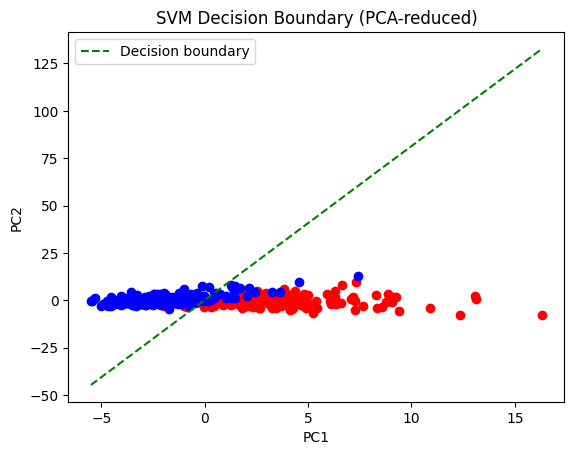

In [ ]:
#visualization(i don't have experience using sklearn yet so i took this visualization code from internet)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Project weight vector onto PCA components
w_pca = model.w @ pca.components_.T

# Plot data points
plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1], color='red', label='Malignant (+1)')
plt.scatter(X_pca[y_train == -1, 0], X_pca[y_train == -1, 1], color='blue', label='Benign (-1)')

# Decision boundary line in PCA space
x_vals = np.linspace(X_pca[:,0].min(), X_pca[:,0].max(), 100)
if w_pca[1] != 0:
    y_vals = - (w_pca[0] * x_vals + model.b) / w_pca[1]
    plt.plot(x_vals, y_vals, color='green', linestyle='--', label='Decision Boundary')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("SVM Decision Boundary (PCA-reduced)")
plt.legend()
plt.show()